# 第056单元 生成解码与KV缓存
先运行全部单元，再改参数。固定模型、160条生成、完整前向对照、边界测试与固定工作量计时。此Notebook不会下载模型或调用API。请把工作目录设为本单元目录。

In [1]:
from pathlib import Path
import json, sys, subprocess, math
import numpy as np
import torch
from IPython.display import display, Image
from experiment import distribution, run, generate, cache_bytes
from model import load_model
root = Path.cwd()
if not (root / 'data/weights.npz').is_file():
    raise RuntimeError('请在056单元目录运行')
print({'python': sys.version.split()[0], 'torch': torch.__version__, 'numpy': np.__version__})

{'python': '3.12.14', 'torch': '2.14.1+cpu', 'numpy': '2.3.5'}


## 1 先算概率再看代码
原概率[0.4,0.3,0.2,0.1]。先写下T=0.5、top-k2和top-p0.6的答案。温度缩放作用于logit；top-p包含首次跨阈值的项。

In [2]:
z = torch.log(torch.tensor([.4,.3,.2,.1], dtype=torch.float64))
for name, cfg in [('温度0.5', {'temperature': .5}), ('top-k2', {'top_k': 2}), ('top-p0.6', {'top_p': .6})]:
    print(name, distribution(z, **cfg).tolist())
if not torch.allclose(distribution(z,.5), torch.tensor([16,9,4,1],dtype=torch.float64)/30):
    raise AssertionError('手算不一致')

温度0.5 [0.5333333333333334, 0.29999999999999993, 0.13333333333333336, 0.033333333333333354]
top-k2 [0.5714285714285714, 0.4285714285714285, 0.0, 0.0]
top-p0.6 [0.5714285714285714, 0.4285714285714285, 0.0, 0.0]


## 2 执行实现边界测试
普通与优化模式都需通过。测试验证过滤、并列规则、因果性、批大小2的分块缓存、实际载荷和停止边界。

In [3]:
for flags in [[], ['-O']]:
    subprocess.run([sys.executable, *flags, 'test_experiment.py'], check=True)
model = load_model(root/'data/weights.npz')
x = torch.tensor([[1,3,7,11,4,15,19],[1,4,8,12,6,17,19]])
a, kv = model.cached(x[:,:3]); b, kv = model.cached(x[:,3:], kv)
with torch.no_grad():
    error = (torch.cat([a,b],1)-model(x)).abs().max().item()
print('最大绝对误差', error, 'KV纯载荷字节', cache_bytes(kv))

最大绝对误差 1.430511474609375e-06 KV纯载荷字节 3584


## 3 重跑固定协议
五组×四prompt×八种子，共160次。记录全部输出，不挑选好看的文本。计时将变化；非时间统计应和随包原记录核对。

In [4]:
result = run(root/'notebook_replay')
print('样本数', len(result['samples']), '最大缓存误差', result['max_cache_logit_abs_error'])
for row in result['summary']:
    print({k:v for k,v in row.items() if k != 'median_cached_ms'})
print('固定工作量中位数ms', result['fixed_workload_median_ms'])

样本数 160 最大缓存误差 1.430511474609375e-06
{'config': 'greedy', 'n': 32, 'mean_length': 6.0, 'eos_fraction': 1.0, 'unique_continuations': 4, 'mean_repeat_fraction': 0.0, 'adjacent_repeat_total': 0}
{'config': 'T0.7', 'n': 32, 'mean_length': 5.875, 'eos_fraction': 1.0, 'unique_continuations': 28, 'mean_repeat_fraction': 0.0, 'adjacent_repeat_total': 0}
{'config': 'T1.3', 'n': 32, 'mean_length': 5.25, 'eos_fraction': 0.625, 'unique_continuations': 32, 'mean_repeat_fraction': 0.0, 'adjacent_repeat_total': 8}
{'config': 'top-k3', 'n': 32, 'mean_length': 6.0, 'eos_fraction': 1.0, 'unique_continuations': 29, 'mean_repeat_fraction': 0.0, 'adjacent_repeat_total': 0}
{'config': 'top-p0.8', 'n': 32, 'mean_length': 6.0, 'eos_fraction': 1.0, 'unique_continuations': 30, 'mean_repeat_fraction': 0.0, 'adjacent_repeat_total': 0}
固定工作量中位数ms {'full': 1.829590500165068, 'cache': 1.8183834999945248}


## 4 逐项核对正式记录
排除秒数后比较tokens、停止理由和重复计数。跨设备/版本不保证相同采样；若差异出现，先保存环境，核对权重SHA和logit，再研究随机数边界。

In [5]:
recorded = json.loads((root/'outputs/results.json').read_text())
keys = ['config','prompt_index','seed','tokens','stop_reason','adjacent_repeat_count']
matching = all(all(a[k] == b[k] for k in keys) for a,b in zip(result['samples'],recorded['samples']))
print('固定样本字段一致', matching)
for row in result['samples']:
    if row['adjacent_repeat_count']:
        print('一个保留的退化样本', {k:row[k] for k in ['config','seed','text','stop_reason','repeated_bigram_fraction','adjacent_repeat_count']})
        break

固定样本字段一致 True
一个保留的退化样本 {'config': 'T1.3', 'seed': 5603, 'text': '鸟 红 蓝 蓝 。 <eos>', 'stop_reason': 'eos', 'repeated_bigram_fraction': 0.0, 'adjacent_repeat_count': 1}


## 5 重画证据图并解释负面结果
图由本次notebook_replay结果生成。注意相邻重复与二元组重复衡量不同现象；短上下文缓存可能没有稳定提速。

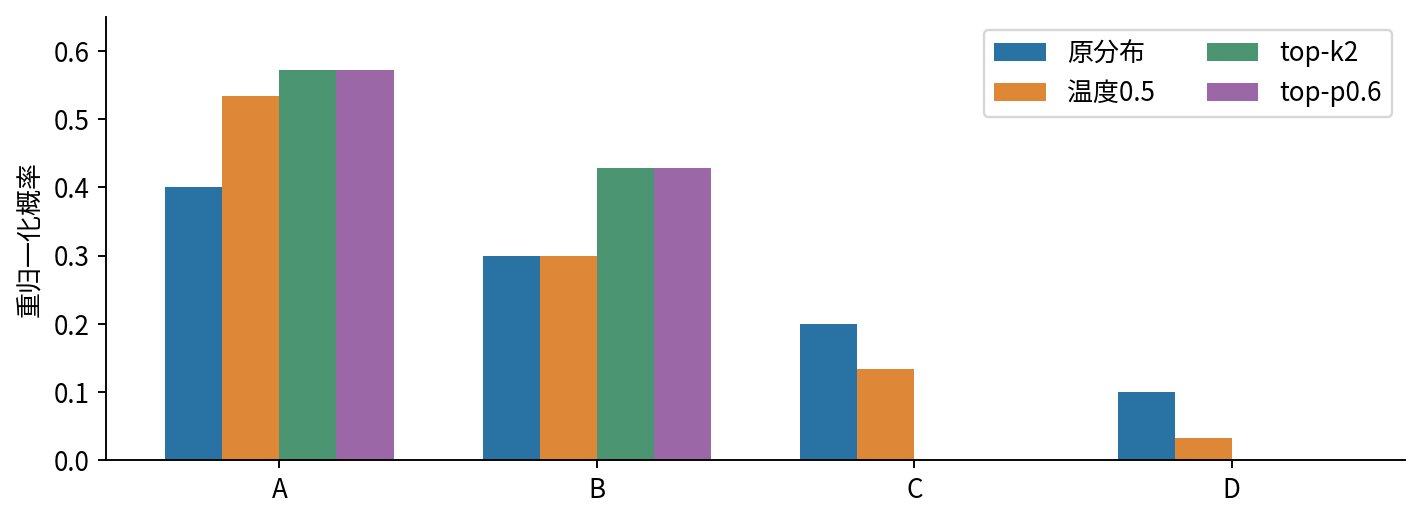

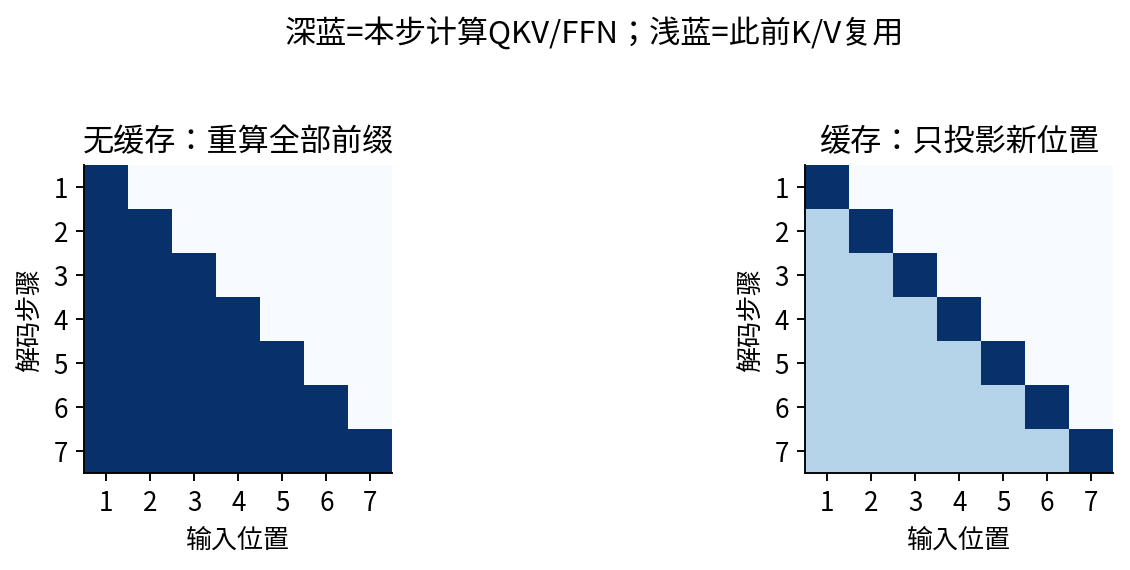

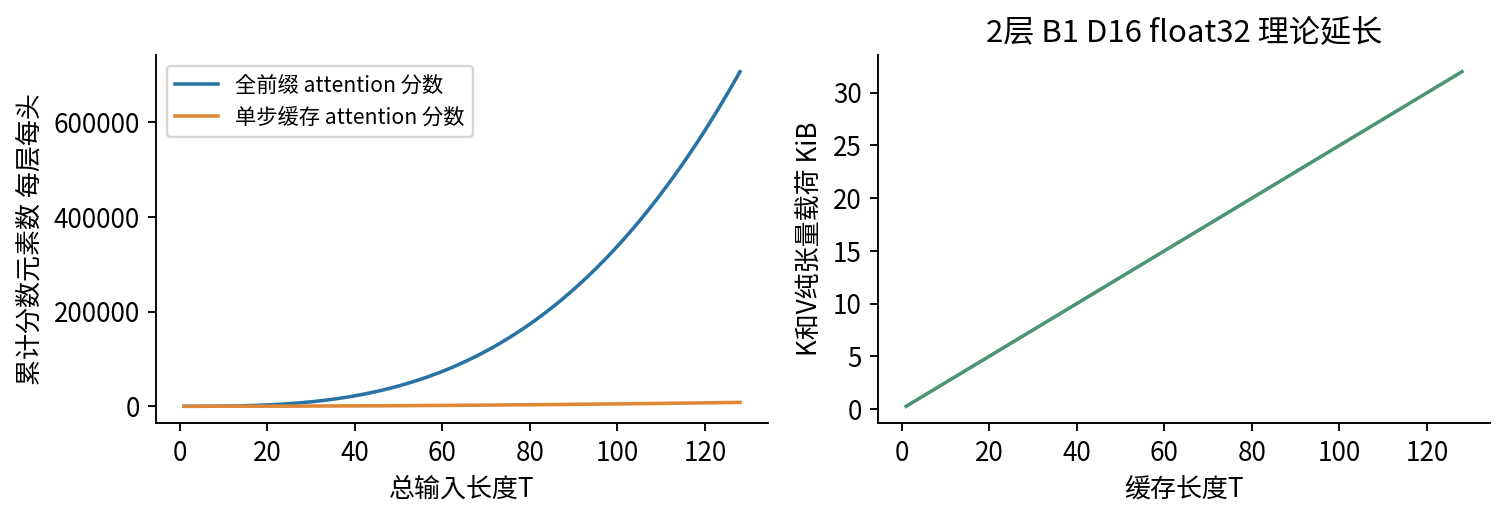

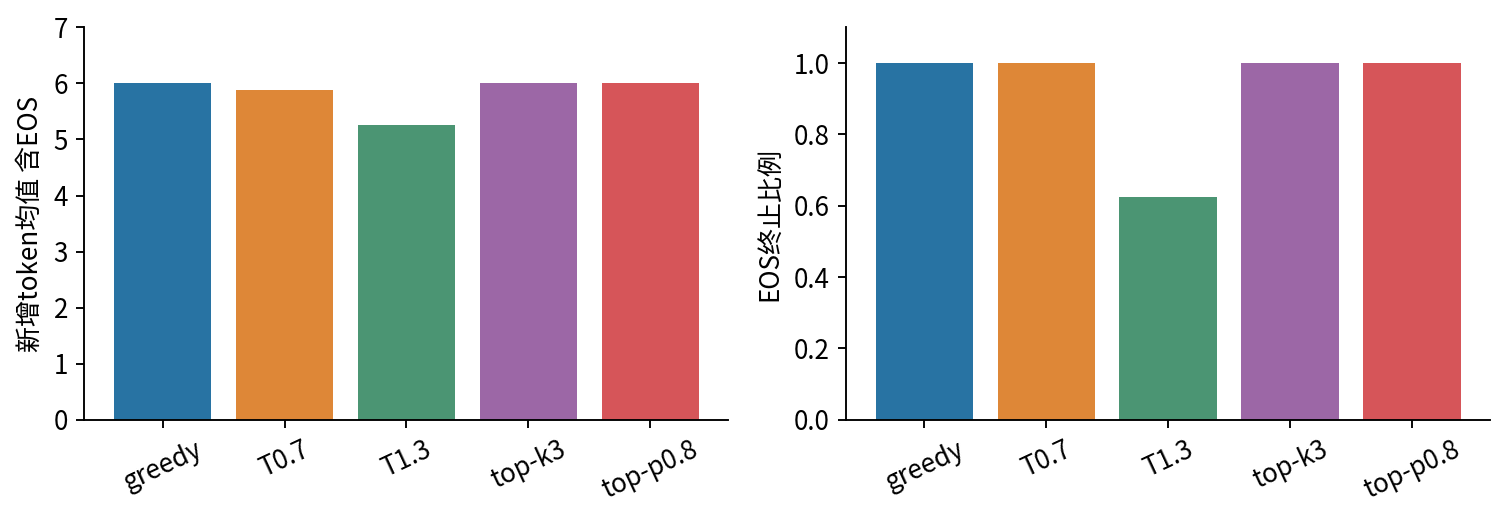

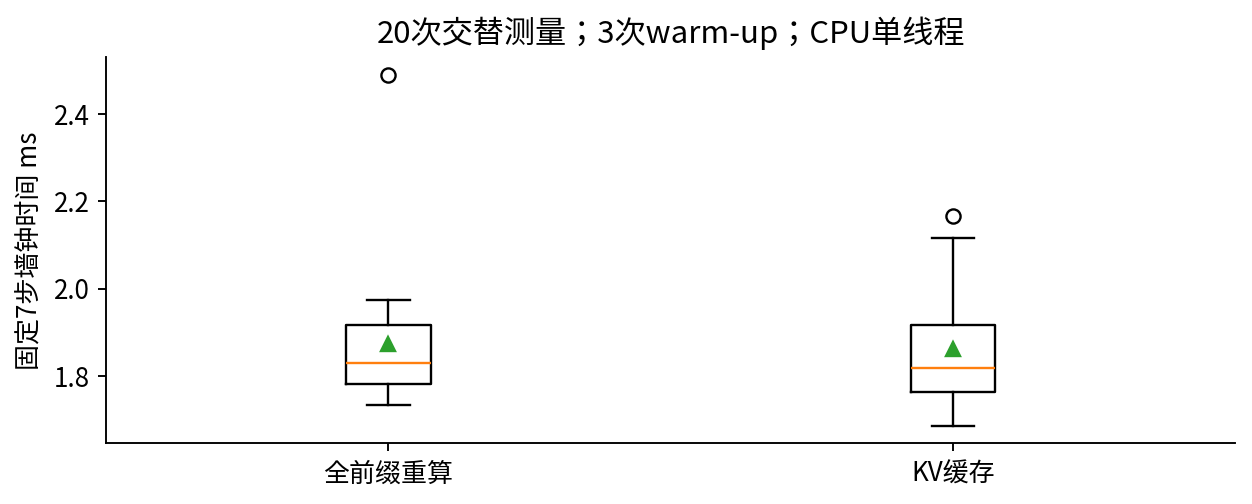

In [6]:
subprocess.run([sys.executable,'make_figures.py','--results','notebook_replay/results.json','--output','notebook_replay/figures'],check=True)
for name in ['01_probabilities.png','02_cache_timeline.png','03_cost_memory.png','04_outputs.png','05_timing.png']:
    display(Image(filename=str(root/'notebook_replay/figures'/name)))

## 6 独立思考与提交
1. 手绘已有3位置、新增2位置的allowed矩阵，并写Q/K/V各shape。
2. 为什么返回8个token仍可使用7位置表？
3. 为什么所有重复二元组比例为0仍不说明没有重复？
4. 1792字节不包括哪些内存？
5. 列出一个缓存没有更快时仍然有效的正确性结论。

提交手算、完整JSON、五张证据图及一页有边界的结果解释。参考答案见answers.pdf。